# 天池工业蒸汽量预测

## 导入库

In [1]:
import os
import numpy as np
import pandas as pd
import joblib

from loguru import logger
from sklearn import svm
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 加载数据

In [2]:
os.makedirs("./outputs", exist_ok=True)

train_data = pd.read_csv("./data/zhengqi_train.txt", sep="\t")
X_test = pd.read_csv("./data/zhengqi_test.txt", sep="\t")

X = train_data.drop(columns="target")
y = train_data["target"]

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
train_data.describe()

,V0,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,target
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000
mean,0.123048,0.056068,0.289720,-0.067790,0.012921,-0.558565,0.182892,0.116155,0.177856,-0.169452,0.034319,-0.364465,0.023177,0.195738,0.016081,0.096146,0.113505,-0.043458,0.055034,-0.114884,-0.186226,-0.056556,0.302893,0.155978,-0.021813,-0.051679,0.072092,0.272407,0.137712,0.097648,0.055477,0.127791,0.020806,0.007801,0.006715,0.197764,0.030658,-0.130330,0.126353
std,0.928031,0.941515,0.911236,0.970298,0.888377,0.517957,0.918054,0.955116,0.895444,0.953813,0.968272,0.858504,0.894092,0.922757,1.015585,1.033048,0.983128,0.655857,0.953466,1.108859,0.788511,0.781471,0.639186,0.978757,1.033403,0.915957,0.889771,0.270374,0.929899,1.061200,0.901934,0.873028,0.902584,1.006995,1.003291,0.985675,0.970812,1.017196,0.983966
min,-4.335000,-5.122000,-3.420000,-3.956000,-4.742000,-2.182000,-4.576000,-5.048000,-4.692000,-12.891000,-2.584000,-3.160000,-5.165000,-3.675000,-2.455000,-2.903000,-5.981000,-2.224000,-3.582000,-3.704000,-3.402000,-2.643000,-1.375000,-5.542000,-1.344000,-3.808000,-5.131000,-1.164000,-2.435000,-2.912000,-4.507000,-5.859000,-4.053000,-4.627000,-4.789000,-5.695000,-2.608000,-3.630000,-3.044000
25%,-0.297000,-0.226250,-0.313000,-0.652250,-0.385000,-0.853000,-0.310000,-0.295000,-0.159000,-0.390000,-0.420500,-0.803250,-0.419000,-0.398000,-0.668000,-0.662250,-0.300000,-0.366000,-0.367500,-0.987500,-0.675500,-0.517000,-0.063000,0.097250,-1.191000,-0.557250,-0.452000,0.157750,-0.455000,-0.664000,-0.283000,-0.170250,-0.407250,-0.499000,-0.290000,-0.202500,-0.413000,-0.798250,-0.350250
50%,0.359000,0.272500,0.386000,-0.044500,0.110000,-0.466000,0.388000,0.344000,0.362000,0.042000,0.157000,-0.112000,0.123000,0.289500,-0.161000,-0.000500,0.306000,0.165000,0.082000,-0.000500,-0.156500,-0.056500,0.216500,0.338000,0.095000,-0.076000,0.075000,0.325000,-0.447000,-0.023000,0.053500,0.299500,0.039000,-0.040000,0.160000,0.364000,0.137000,-0.185500,0.313000
75%,0.726000,0.599000,0.918250,0.624000,0.550250,-0.154000,0.831250,0.782250,0.726000,0.042000,0.619250,0.247000,0.616000,0.864250,0.829750,0.730000,0.774250,0.430000,0.513250,0.737250,0.304000,0.431500,0.872000,0.368250,0.931250,0.356000,0.644250,0.442000,0.730000,0.745250,0.488000,0.635000,0.557000,0.462000,0.273000,0.602000,0.644250,0.495250,0.793250
max,2.121000,1.918000,2.828000,2.457000,2.689000,0.489000,1.895000,1.918000,2.245000,1.335000,4.830000,1.455000,2.657000,2.475000,2.558000,4.314000,2.861000,2.023000,4.441000,3.431000,3.525000,2.259000,2.018000,1.906000,2.423000,7.284000,2.980000,0.925000,4.671000,4.580000,2.689000,2.013000,2.395000,5.465000,5.110000,2.324000,5.238000,3.000000,2.538000


## 使用SVR（不同核函数）支持向量机建模预测
### rbf

In [3]:
def evaluate_model(name, model, X_tr, y_tr, X_val, y_val):
    model.fit(X_tr, y_tr)
    val_pred = model.predict(X_val)

    mse = mean_squared_error(y_val, val_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val, val_pred)
    r2 = r2_score(y_val, val_pred)

    logger.info(f"{name} -> MSE: {mse:.6f}, RMSE: {rmse:.6f}, MAE: {mae:.6f}, R2: {r2:.6f}")

    return {
        "model": name,
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "val_pred": val_pred
    }


In [4]:
models = {
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01, random_state=42, max_iter=10000))
    ]),
    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=10000))
    ]),
    'SVR-linear': Pipeline([
        ('scaler', StandardScaler()),
        ('model', svm.SVR(kernel='linear', C=10, epsilon=0.1))
    ]),
    'SVR-rbf': Pipeline([
        ('scaler', StandardScaler()),
        ('model', svm.SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.1))
    ]),
    'SVR-poly': Pipeline([
        ('scaler', StandardScaler()),
        ('model', svm.SVR(kernel='poly', degree=3, C=10, epsilon=0.1, gamma='scale'))
    ]),
    'SVR-sigmoid': Pipeline([
        ('scaler', StandardScaler()),
        ('model', svm.SVR(kernel='sigmoid', C=10, epsilon=0.1, gamma='scale'))
    ])
}


## baseline

In [5]:
results = []
val_pred_dict = {}

for name, model in models.items():
    res = evaluate_model(name, model, X_tr, y_tr, X_val, y_val)
    results.append({
        "model": res["model"],
        "mse": res["mse"],
        "rmse": res["rmse"],
        "mae": res["mae"],
        "r2": res["r2"]
    })
    val_pred_dict[name] = res["val_pred"]

results_df = pd.DataFrame(results).sort_values(by="rmse")
print("单模型结果：")
print(results_df)

2026-04-04 23:38:45.309 | INFO     | __main__:evaluate_model:10 - Lasso -> MSE: 0.109157, RMSE: 0.330389, MAE: 0.246221, R2: 0.885921
2026-04-04 23:38:45.313 | INFO     | __main__:evaluate_model:10 - ElasticNet -> MSE: 0.105022, RMSE: 0.324070, MAE: 0.240645, R2: 0.890242
2026-04-04 23:38:52.065 | INFO     | __main__:evaluate_model:10 - SVR-linear -> MSE: 0.095232, RMSE: 0.308596, MAE: 0.230037, R2: 0.900474
2026-04-04 23:38:52.349 | INFO     | __main__:evaluate_model:10 - SVR-rbf -> MSE: 0.120828, RMSE: 0.347604, MAE: 0.246612, R2: 0.873723
2026-04-04 23:38:52.988 | INFO     | __main__:evaluate_model:10 - SVR-poly -> MSE: 0.446017, RMSE: 0.667845, MAE: 0.344516, R2: 0.533868
2026-04-04 23:38:53.185 | INFO     | __main__:evaluate_model:10 - SVR-sigmoid -> MSE: 26790.552978, RMSE: 163.678199, MAE: 62.716804, R2: -27997.751266


单模型结果：
         model           mse        rmse        mae            r2
2   SVR-linear      0.095232    0.308596   0.230037      0.900474
1   ElasticNet      0.105022    0.324070   0.240645      0.890242
0        Lasso      0.109157    0.330389   0.246221      0.885921
3      SVR-rbf      0.120828    0.347604   0.246612      0.873723
4     SVR-poly      0.446017    0.667845   0.344516      0.533868
5  SVR-sigmoid  26790.552978  163.678199  62.716804 -27997.751266


In [6]:
fusion_pred_1 = 0.8 * val_pred_dict["ElasticNet"] + 0.2 * val_pred_dict["SVR-rbf"]
fusion_pred_2 = (
    0.2 * val_pred_dict["Lasso"] +
    0.5 * val_pred_dict["ElasticNet"] +
    0.3 * val_pred_dict["SVR-rbf"]
)
fusion_pred_3 = (
    val_pred_dict["Lasso"] +
    val_pred_dict["ElasticNet"] +
    val_pred_dict["SVR-rbf"]
) / 3

fusion_results = []

for name, pred in {
    "Fusion1_ElasticNet0.8_SVRrbf0.2": fusion_pred_1,
    "Fusion2_Lasso0.2_ElasticNet0.5_SVRrbf0.3": fusion_pred_2,
    "Fusion3_Average": fusion_pred_3
}.items():
    mse = mean_squared_error(y_val, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val, pred)
    r2 = r2_score(y_val, pred)

    logger.info(f"{name} -> MSE: {mse:.6f}, RMSE: {rmse:.6f}, MAE: {mae:.6f}, R2: {r2:.6f}")

    fusion_results.append({
        "model": name,
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    })

fusion_df = pd.DataFrame(fusion_results)
print("融合模型结果：")
print(fusion_df)


2026-04-04 23:39:20.252 | INFO     | __main__:<module>:25 - Fusion1_ElasticNet0.8_SVRrbf0.2 -> MSE: 0.094579, RMSE: 0.307537, MAE: 0.224522, R2: 0.901156
2026-04-04 23:39:20.253 | INFO     | __main__:<module>:25 - Fusion2_Lasso0.2_ElasticNet0.5_SVRrbf0.3 -> MSE: 0.092409, RMSE: 0.303989, MAE: 0.219767, R2: 0.903424
2026-04-04 23:39:20.254 | INFO     | __main__:<module>:25 - Fusion3_Average -> MSE: 0.092255, RMSE: 0.303735, MAE: 0.218875, R2: 0.903584


融合模型结果：
                                      model       mse      rmse       mae  \
0           Fusion1_ElasticNet0.8_SVRrbf0.2  0.094579  0.307537  0.224522   
1  Fusion2_Lasso0.2_ElasticNet0.5_SVRrbf0.3  0.092409  0.303989  0.219767   
2                           Fusion3_Average  0.092255  0.303735  0.218875   

         r2  
0  0.901156  
1  0.903424  
2  0.903584  


In [7]:
all_results_df = pd.concat([results_df, fusion_df], ignore_index=True).sort_values(by="rmse")
print("全部结果对比：")
print(all_results_df)


全部结果对比：
                                      model           mse        rmse  \
8                           Fusion3_Average      0.092255    0.303735   
7  Fusion2_Lasso0.2_ElasticNet0.5_SVRrbf0.3      0.092409    0.303989   
6           Fusion1_ElasticNet0.8_SVRrbf0.2      0.094579    0.307537   
0                                SVR-linear      0.095232    0.308596   
1                                ElasticNet      0.105022    0.324070   
2                                     Lasso      0.109157    0.330389   
3                                   SVR-rbf      0.120828    0.347604   
4                                  SVR-poly      0.446017    0.667845   
5                               SVR-sigmoid  26790.552978  163.678199   

         mae            r2  
8   0.218875      0.903584  
7   0.219767      0.903424  
6   0.224522      0.901156  
0   0.230037      0.900474  
1   0.240645      0.890242  
2   0.246221      0.885921  
3   0.246612      0.873723  
4   0.344516      0.533868  


In [8]:
best_rmse = float("inf")
best_weight = None

for w in np.arange(0.0, 1.01, 0.1):
    pred = w * val_pred_dict["ElasticNet"] + (1 - w) * val_pred_dict["SVR-rbf"]
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    if rmse < best_rmse:
        best_rmse = rmse
        best_weight = w

print(f"最佳双模型权重: ElasticNet={best_weight:.1f}, SVR-rbf={1-best_weight:.1f}")
print(f"最佳双模型RMSE: {best_rmse:.6f}")

最佳双模型权重: ElasticNet=0.6, SVR-rbf=0.4
最佳双模型RMSE: 0.301560


In [9]:
final_models = {
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01, random_state=42, max_iter=10000))
    ]),
    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=10000))
    ]),
    'SVR-rbf': Pipeline([
        ('scaler', StandardScaler()),
        ('model', svm.SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.1))
    ])
}

for name, model in final_models.items():
    model.fit(X, y)
    joblib.dump(model, f"./outputs/{name}.pkl")

lasso_test_pred = final_models["Lasso"].predict(X_test)
elastic_test_pred = final_models["ElasticNet"].predict(X_test)
svr_rbf_test_pred = final_models["SVR-rbf"].predict(X_test)

final_pred = (
    0.2 * lasso_test_pred +
    0.5 * elastic_test_pred +
    0.3 * svr_rbf_test_pred
)

np.savetxt("./outputs/fusion_pred.txt", final_pred)
print("最终融合预测已保存到 ./outputs/fusion_pred.txt")

最终融合预测已保存到 ./outputs/fusion_pred.txt


In [10]:
pred_df = pd.DataFrame({
    "Lasso": lasso_test_pred,
    "ElasticNet": elastic_test_pred,
    "SVR-rbf": svr_rbf_test_pred,
    "Fusion": final_pred
})

pred_df.head()

,Lasso,ElasticNet,SVR-rbf,Fusion
0,0.205788,0.240981,0.517197,0.316807
1,0.182935,0.214506,0.488287,0.290326
2,-0.115547,-0.075268,0.259440,0.017088
3,0.040092,0.062623,0.481686,0.183835
4,0.281766,0.295752,0.728419,0.422755


## 预测分布直方图

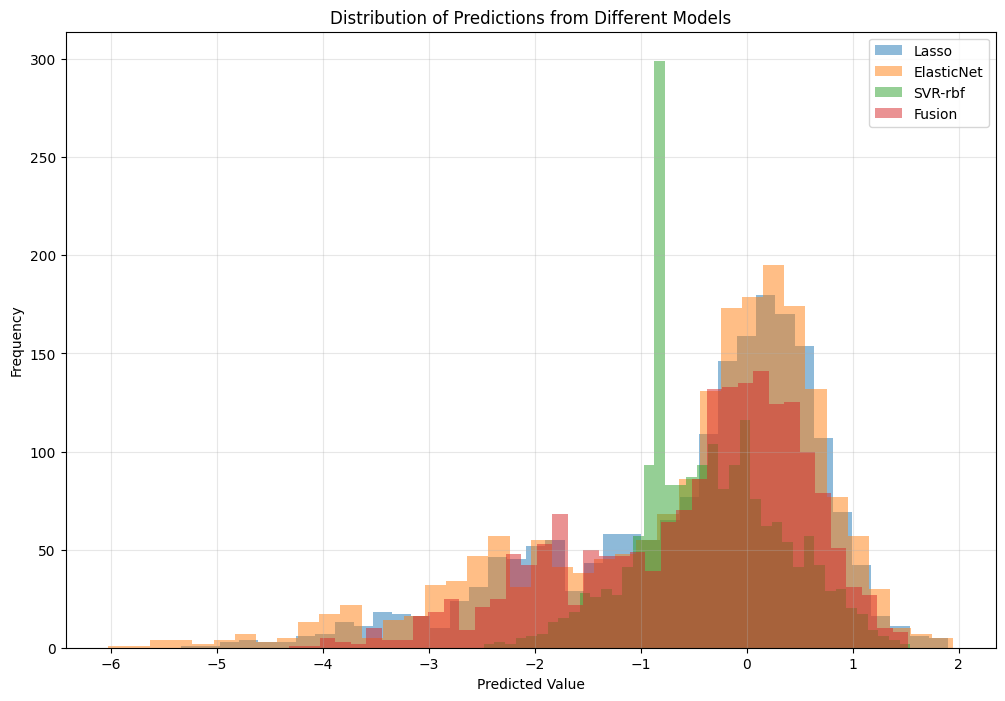

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.hist(pred_df["Lasso"], bins=40, alpha=0.5, label="Lasso")
plt.hist(pred_df["ElasticNet"], bins=40, alpha=0.5, label="ElasticNet")
plt.hist(pred_df["SVR-rbf"], bins=40, alpha=0.5, label="SVR-rbf")
plt.hist(pred_df["Fusion"], bins=40, alpha=0.5, label="Fusion")

plt.xlabel("Predicted Value")
plt.ylabel("Frequency")
plt.title("Distribution of Predictions from Different Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 融合前后对比图

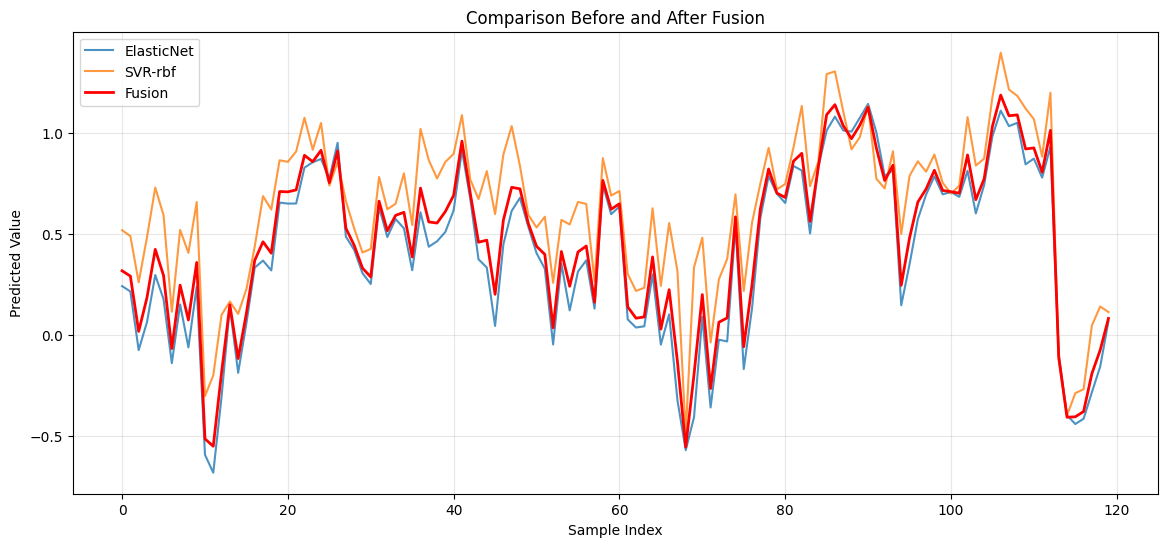

In [16]:
plt.figure(figsize=(14, 6))

n_show = 120
plt.plot(pred_df["ElasticNet"][:n_show].values, label="ElasticNet", alpha=0.8)
plt.plot(pred_df["SVR-rbf"][:n_show].values, label="SVR-rbf", alpha=0.8)
plt.plot(pred_df["Fusion"][:n_show].values, label="Fusion", color="red", linewidth=2)

plt.title("Comparison Before and After Fusion")
plt.xlabel("Sample Index")
plt.ylabel("Predicted Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()